In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/BloodPressureDataset/part_4.mat
/kaggle/input/BloodPressureDataset/part_9.mat
/kaggle/input/BloodPressureDataset/part_10.mat
/kaggle/input/BloodPressureDataset/part_11.mat
/kaggle/input/BloodPressureDataset/part_3.mat
/kaggle/input/BloodPressureDataset/part_1.mat
/kaggle/input/BloodPressureDataset/part_8.mat
/kaggle/input/BloodPressureDataset/part_5.mat
/kaggle/input/BloodPressureDataset/part_6.mat
/kaggle/input/BloodPressureDataset/part_7.mat
/kaggle/input/BloodPressureDataset/part_2.mat
/kaggle/input/BloodPressureDataset/part_12.mat
/kaggle/input/BloodPressureDataset/Samples/rec_235.csv
/kaggle/input/BloodPressureDataset/Samples/rec_389.csv
/kaggle/input/BloodPressureDataset/Samples/rec_397.csv
/kaggle/input/BloodPressureDataset/Samples/rec_395.csv
/kaggle/input/BloodPressureDataset/Samples/rec_338.csv
/kaggle/input/BloodPressureDataset/Samples/rec_11.csv
/kaggle/input/BloodPressureDataset/Samples/rec_431.csv
/kaggle/input/BloodPressureDataset/Samples/rec_454.csv
/kaggl

In [2]:
import scipy.io
import matplotlib.pyplot as plt

# Đường dẫn tới file
mat = scipy.io.loadmat('/kaggle/input/BloodPressureDataset/part_1.mat')

# Xem các key có trong file
print(mat.keys())


dict_keys(['__header__', '__version__', '__globals__', 'p'])


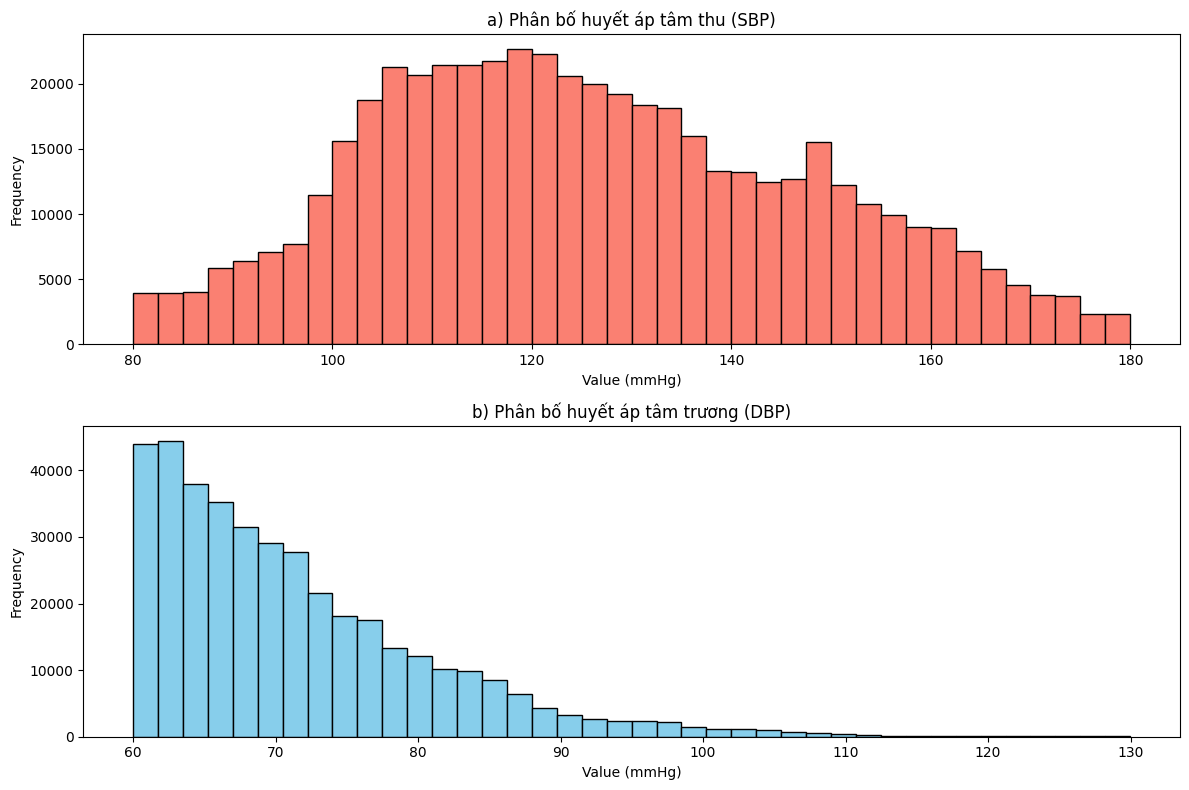

In [3]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import os

# --- Thông số chuẩn hóa ---
fs = 125  # Tần số lấy mẫu
min_length = 9 * 60 * fs  # 10 phút dữ liệu

# --- Đường dẫn thư mục chứa các file .mat ---
folder_path = '/kaggle/input/BloodPressureDataset'
file_list = [f for f in os.listdir(folder_path) if f.endswith('.mat')]

all_sbp = []
all_dbp = []

for file_name in file_list:
    mat = scipy.io.loadmat(os.path.join(folder_path, file_name))
    if 'p' not in mat:
        continue
    p = mat['p']

    for i in range(p.shape[1]):
        sample = p[0, i]
        if sample.shape[0] < 2:
            continue

        abp = sample[1].flatten()
        if len(abp) < min_length:
            continue  # Bỏ record ngắn hơn 10 phút

        # Tìm đỉnh (SYS) và đáy (DIA)
        peaks, _ = find_peaks(abp, distance=100)
        troughs, _ = find_peaks(-abp, distance=100)

        sbp = abp[peaks]
        dbp = abp[troughs]

        # Lọc theo ngưỡng sinh lý hợp lý
        sbp = sbp[(sbp >= 80) & (sbp <= 180)]
        dbp = dbp[(dbp >= 60) & (dbp <= 130)]

        all_sbp.extend(sbp)
        all_dbp.extend(dbp)

# --- Chuyển sang numpy array ---
all_sbp = np.array(all_sbp)
all_dbp = np.array(all_dbp)

# --- Vẽ biểu đồ phân bố ---
plt.figure(figsize=(12, 8))

# a) SBP
plt.subplot(2, 1, 1)
plt.hist(all_sbp, bins=40, color='salmon', edgecolor='black')
plt.title("a) Phân bố huyết áp tâm thu (SBP)")
plt.xlabel("Value (mmHg)")
plt.ylabel("Frequency")

# b) DBP
plt.subplot(2, 1, 2)
plt.hist(all_dbp, bins=40, color='skyblue', edgecolor='black')
plt.title("b) Phân bố huyết áp tâm trương (DBP)")
plt.xlabel("Value (mmHg)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


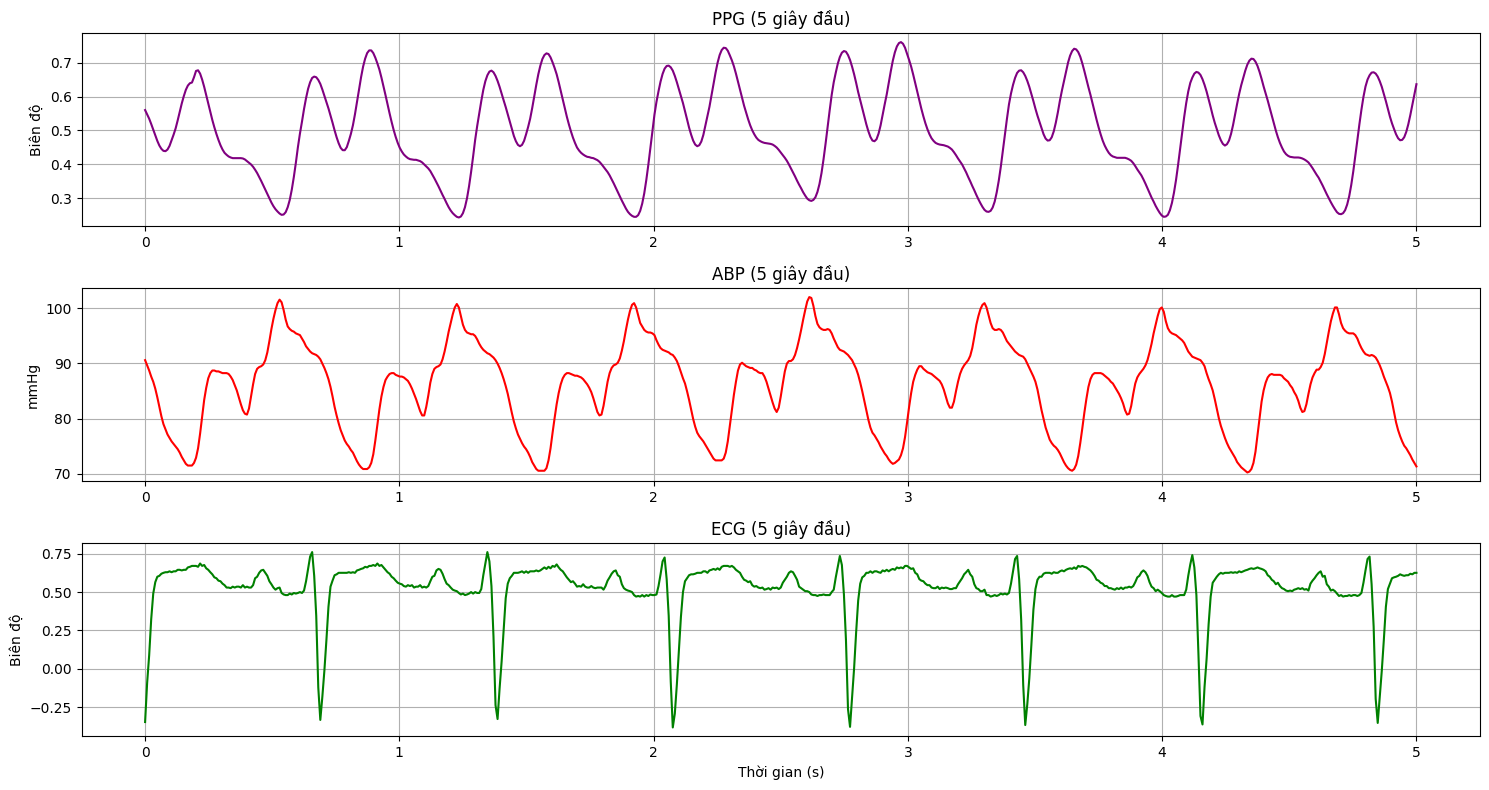

In [4]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import os

# Đường dẫn đến thư mục chứa file
folder_path = '/kaggle/input/BloodPressureDataset'
file_list = [f for f in os.listdir(folder_path) if f.endswith('.mat')]

# Đọc 1 file bất kỳ (ví dụ: file đầu tiên)
mat = scipy.io.loadmat(os.path.join(folder_path, file_list[0]))

# Lấy biến 'p' (chứa dữ liệu tín hiệu)
p = mat['p']

# Lấy 1 sample bất kỳ (ví dụ: sample đầu tiên)
sample = p[0, 0]

# Tín hiệu:
ppg = sample[0].flatten()  # PPG (row 0)
abp = sample[1].flatten()  # ABP (row 1)
ecg = sample[2].flatten()  # ECG (row 2)

# Tạo vector thời gian
fs = 125  # tần số lấy mẫu
duration_sec = 5  # 5 giây
num_samples = fs * duration_sec
t = np.linspace(0, duration_sec, num_samples)

# Vẽ
plt.figure(figsize=(15, 8))

plt.subplot(3, 1, 1)
plt.plot(t, ppg[:num_samples], color='purple')
plt.title("PPG (5 giây đầu)")
plt.ylabel("Biên độ")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(t, abp[:num_samples], color='red')
plt.title("ABP (5 giây đầu)")
plt.ylabel("mmHg")
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(t, ecg[:num_samples], color='green')
plt.title("ECG (5 giây đầu)")
plt.xlabel("Thời gian (s)")
plt.ylabel("Biên độ")
plt.grid(True)

plt.tight_layout()
plt.show()


In [5]:
# Loading a sample .mat file to understand the data dimensions
test_sample = scipy.io.loadmat(f'../input/BloodPressureDataset/part_{1}.mat')['p']
print(f'test_sample Data type: {type(test_sample)}')
print(f'test_sample shape/dimensions: {test_sample.shape}')

test_sample Data type: <class 'numpy.ndarray'>
test_sample shape/dimensions: (1, 1000)


In [6]:
print(f"Total Samples: {len(test_sample[0])}")
print(f"Number of readings in each sample(column): {len(test_sample[0][0])}")
print(f"Number of samples in each reading(ECG): {len(test_sample[0][0][2])}")

temp_mat = test_sample[0, 999]
temp_length = temp_mat.shape[1]
sample_size = 125


print(temp_length)
print((int)(temp_length/sample_size))

Total Samples: 1000
Number of readings in each sample(column): 3
Number of samples in each reading(ECG): 61000
9000
72


In [7]:
sample_size = 125
ppg = []
for i in range(1000):
    temp_mat = test_sample[0, i]
    temp_length = temp_mat.shape[1]
    for j in range((int)(temp_length/sample_size)):
        temp_ppg = temp_mat[0, j*sample_size:(j+1)*sample_size]
        ppg.append(temp_ppg)

In [8]:
ecg = []
bp = []
sbp = [] #Systolic Blood Pressure
dbp = [] #Diastolic Blood Pressue
size = 125 #sample size

for i in range(1000):
    temp_mat = test_sample[0, i]
    temp_length = temp_mat.shape[1]
    for j in range((int)(temp_length/sample_size)):
        temp_ecg = temp_mat[2, j*size:(j+1)*size]
        temp_bp = temp_mat[1, j*size:(j+1)*size]
        
        max_value = max(temp_bp)
        min_value = min(temp_bp)
        
        sbp.append(max_value)
        dbp.append(min_value)
        ecg.append(temp_ecg)
        bp.append(temp_bp)

In [9]:
# Reshaping the ecg, ppg and bp signal data into column vectors
ppg, ecg, bp = np.array(ppg).reshape(-1,1), np.array(ecg).reshape(-1,1), np.array(bp).reshape(-1,1)
sbp, dbp = np.array(sbp).reshape(-1,1), np.array(dbp).reshape(-1,1)
print(f'PPG_shape: {ppg.shape}\n ECG_shape: {ecg.shape}\n BP_shape: {bp.shape}')
print(f'Systolic-BP_shape: {sbp.shape},\n Diastolic-BP_shape: {dbp.shape}')

PPG_shape: (32061000, 1)
 ECG_shape: (32061000, 1)
 BP_shape: (32061000, 1)
Systolic-BP_shape: (256488, 1),
 Diastolic-BP_shape: (256488, 1)


In [10]:
import numpy as np
from scipy.signal import find_peaks

fs = 125  # Hz
window_size = fs  # 1s window

# Khởi tạo danh sách chứa các đặc trưng
features = {
    "PTT": [],
    "HeartRate": [],
    "SysVolChange": [],
    "SysMaxVolChange": [],
    "DiaMaxVolChange": [],
    "PWIR": [],
    "HRV": [],
    "SDNN": [],
    "RMSSD": []
}

def extract_features(ecg, ppg, bp, window_size=125, fs=125):
    for i in range(0, len(ecg), window_size):
        # Cắt từng đoạn tín hiệu 1s
        ecg_win = ecg[i:i+window_size].flatten()
        ppg_win = ppg[i:i+window_size].flatten()
        abp_win = bp[i:i+window_size].flatten()

        if len(ecg_win) < window_size or len(ppg_win) < window_size:
            continue

        # === 1. Pulse Transit Time (PTT)
        ecg_peaks, _ = find_peaks(ecg_win, height=np.mean(ecg_win) + 0.5*np.std(ecg_win), distance=30)
        ppg_peaks, _ = find_peaks(ppg_win, distance=30)

        if len(ecg_peaks) > 0 and len(ppg_peaks) > 0:
            ptt = (ppg_peaks[0] - ecg_peaks[0]) / fs
        else:
            ptt = np.nan

        # === 2. Heart Rate (bpm)
        if len(ecg_peaks) > 1:
            rr_intervals = np.diff(ecg_peaks) / fs
            hr = 60 / np.mean(rr_intervals)
        else:
            hr = np.nan

        # === 3. Systolic Volume Change
        sys_vol_change = np.max(ppg_win) - np.mean(ppg_win)

        # === 4. Systolic Max Volume Change (1st derivative)
        sys_max_deriv = np.max(np.diff(ppg_win))

        # === 5. Diastolic Max Volume Change (1st derivative min)
        dia_max_deriv = np.min(np.diff(ppg_win))

        # === 6. Pulse Wave Intensity Ratio (PWIR)
        pwir = sys_max_deriv / abs(dia_max_deriv) if dia_max_deriv != 0 else np.nan

        # === 7. Heart Rate Variability (HRV - SD of RR intervals)
        hrv = np.std(rr_intervals) if len(ecg_peaks) > 2 else np.nan

        # === 8. SDNN
        sdnn = np.std(rr_intervals) if len(ecg_peaks) > 2 else np.nan

        # === 9. RMSSD
        rmssd = np.sqrt(np.mean(np.square(np.diff(rr_intervals)))) if len(ecg_peaks) > 3 else np.nan

        # === Ghi lại
        features["PTT"].append(ptt)
        features["HeartRate"].append(hr)
        features["SysVolChange"].append(sys_vol_change)
        features["SysMaxVolChange"].append(sys_max_deriv)
        features["DiaMaxVolChange"].append(dia_max_deriv)
        features["PWIR"].append(pwir)
        features["HRV"].append(hrv)
        features["SDNN"].append(sdnn)
        features["RMSSD"].append(rmssd)

    return features


In [11]:
features_dict = extract_features(ecg, ppg, bp, window_size=125, fs=125)

# Chuyển sang DataFrame để train
import pandas as pd
X = pd.DataFrame(features_dict).dropna()


In [12]:
# Lấy lại nhãn đầu ra (giá trị SBP & DBP) tương ứng với các đặc trưng còn lại
y_sbp = sbp[:len(X)]
y_dbp = dbp[:len(X)]


In [13]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

# Giả sử X đã là DataFrame đặc trưng
# y_sbp và y_dbp là np.array tương ứng (shape = [n_samples, 1])

# Gộp SBP và DBP lại để chia dữ liệu
y_all = np.concatenate([y_sbp, y_dbp], axis=1)

# Train-test split
X_train, X_test, y_train_all, y_test_all = train_test_split(X, y_all, test_size=0.2, random_state=42)

# Tách SBP và DBP
y_sbp_train, y_dbp_train = y_train_all[:, 0], y_train_all[:, 1]
y_sbp_test, y_dbp_test = y_test_all[:, 0], y_test_all[:, 1]

# K-Fold cross-validation trên tập train
kf = KFold(n_splits=5, shuffle=True, random_state=42)

sbp_mae_list = []
sbp_std_list = []
dbp_mae_list = []
dbp_std_list = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    print(f"\n🔁 Fold {fold + 1}")

    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr_sbp, y_val_sbp = y_sbp_train[train_idx], y_sbp_train[val_idx]
    y_tr_dbp, y_val_dbp = y_dbp_train[train_idx], y_dbp_train[val_idx]

    # Train Random Forest
    rf_sbp = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_dbp = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

    rf_sbp.fit(X_tr, y_tr_sbp)
    rf_dbp.fit(X_tr, y_tr_dbp)

    # Dự đoán trên tập validation
    sbp_pred = rf_sbp.predict(X_val)
    dbp_pred = rf_dbp.predict(X_val)

    # Tính MAE và STD
    sbp_errors = np.abs(y_val_sbp - sbp_pred)
    dbp_errors = np.abs(y_val_dbp - dbp_pred)

    sbp_mae = np.mean(sbp_errors)
    dbp_mae = np.mean(dbp_errors)
    sbp_std = np.std(sbp_errors)
    dbp_std = np.std(dbp_errors)

    print(f"📈 SBP MAE: {sbp_mae:.2f}, STD: {sbp_std:.2f}")
    print(f"📉 DBP MAE: {dbp_mae:.2f}, STD: {dbp_std:.2f}")

    sbp_mae_list.append(sbp_mae)
    dbp_mae_list.append(dbp_mae)
    sbp_std_list.append(sbp_std)
    dbp_std_list.append(dbp_std)

# Đánh giá trung bình và độ lệch chuẩn
print("\n📊 Đánh giá trung bình trên 5 fold:")
print(f"✅ SBP MAE: {np.mean(sbp_mae_list):.2f} ± {np.std(sbp_mae_list):.2f}")
print(f"✅ SBP STD: {np.mean(sbp_std_list):.2f}")
print(f"✅ DBP MAE: {np.mean(dbp_mae_list):.2f} ± {np.std(dbp_mae_list):.2f}")
print(f"✅ DBP STD: {np.mean(dbp_std_list):.2f}")

# Train lại toàn bộ trên tập train để đánh giá test set
rf_sbp.fit(X_train, y_sbp_train)
rf_dbp.fit(X_train, y_dbp_train)

sbp_test_pred = rf_sbp.predict(X_test)
dbp_test_pred = rf_dbp.predict(X_test)

# Tính MAE và STD trên test
mae_sbp = mean_absolute_error(y_sbp_test, sbp_test_pred)
mae_dbp = mean_absolute_error(y_dbp_test, dbp_test_pred)
std_sbp = np.std(np.abs(y_sbp_test - sbp_test_pred))
std_dbp = np.std(np.abs(y_dbp_test - dbp_test_pred))




🔁 Fold 1
📈 SBP MAE: 3.64, STD: 3.21
📉 DBP MAE: 3.27, STD: 3.28

🔁 Fold 2
📈 SBP MAE: 3.69, STD: 3.82
📉 DBP MAE: 3.50, STD: 3.84

🔁 Fold 3
📈 SBP MAE: 3.48, STD: 3.31
📉 DBP MAE: 3.27, STD: 3.30

🔁 Fold 4
📈 SBP MAE: 3.44, STD: 3.16
📉 DBP MAE: 3.13, STD: 3.31

🔁 Fold 5
📈 SBP MAE: 3.41, STD: 3.48
📉 DBP MAE: 3.28, STD: 3.32

📊 Đánh giá trung bình trên 5 fold:
✅ SBP MAE: 3.53 ± 0.11
✅ SBP STD: 3.40
✅ DBP MAE: 3.29 ± 0.12
✅ DBP STD: 3.41


/tmp/ipykernel_19/3979042868.py:29: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_19/3979042868.py:29: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


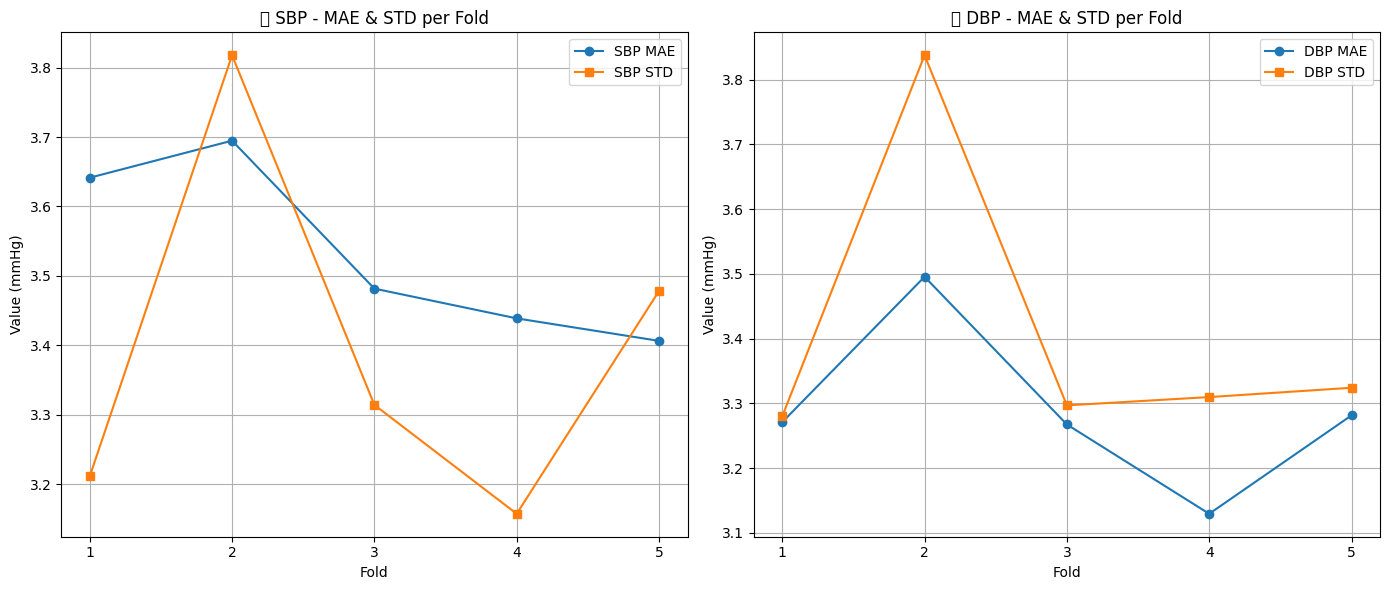

In [14]:
import matplotlib.pyplot as plt

folds = np.arange(1, 6)

plt.figure(figsize=(14, 6))

# SBP
plt.subplot(1, 2, 1)
plt.plot(folds, sbp_mae_list, marker='o', label='SBP MAE')
plt.plot(folds, sbp_std_list, marker='s', label='SBP STD')
plt.title('📈 SBP - MAE & STD per Fold')
plt.xlabel('Fold')
plt.ylabel('Value (mmHg)')
plt.xticks(folds)
plt.legend()
plt.grid(True)

# DBP
plt.subplot(1, 2, 2)
plt.plot(folds, dbp_mae_list, marker='o', label='DBP MAE')
plt.plot(folds, dbp_std_list, marker='s', label='DBP STD')
plt.title('📉 DBP - MAE & STD per Fold')
plt.xlabel('Fold')
plt.ylabel('Value (mmHg)')
plt.xticks(folds)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


/tmp/ipykernel_19/3595853883.py:19: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_19/3595853883.py:20: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.savefig("bp_true_vs_predsbp.png", dpi=300)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


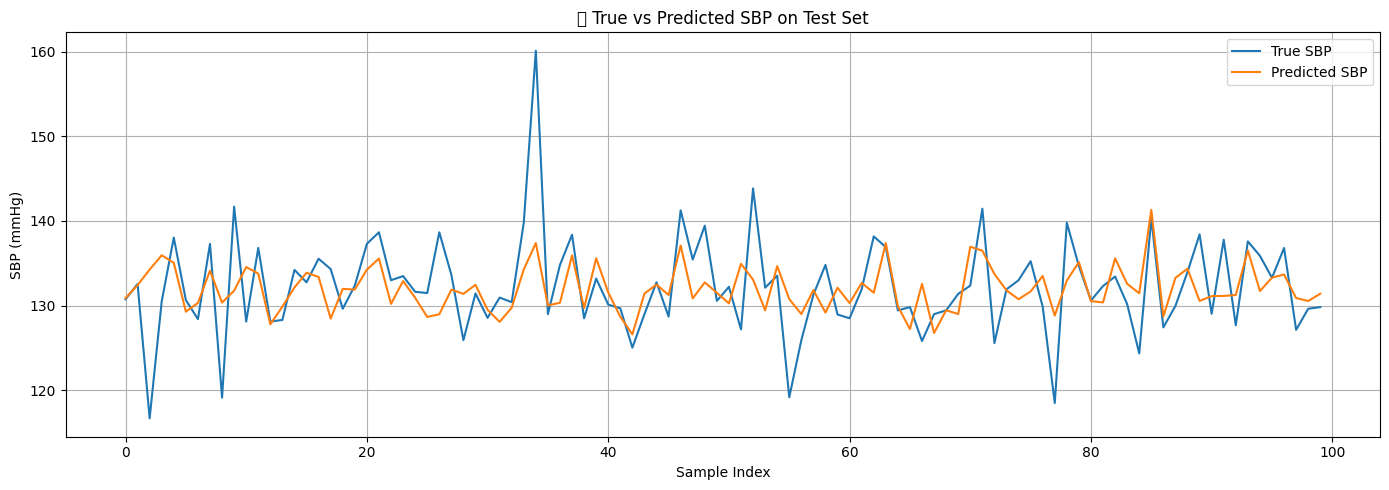

/tmp/ipykernel_19/3595853883.py:32: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_19/3595853883.py:33: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  plt.savefig("bp_true_vs_preddbp.png", dpi=300)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


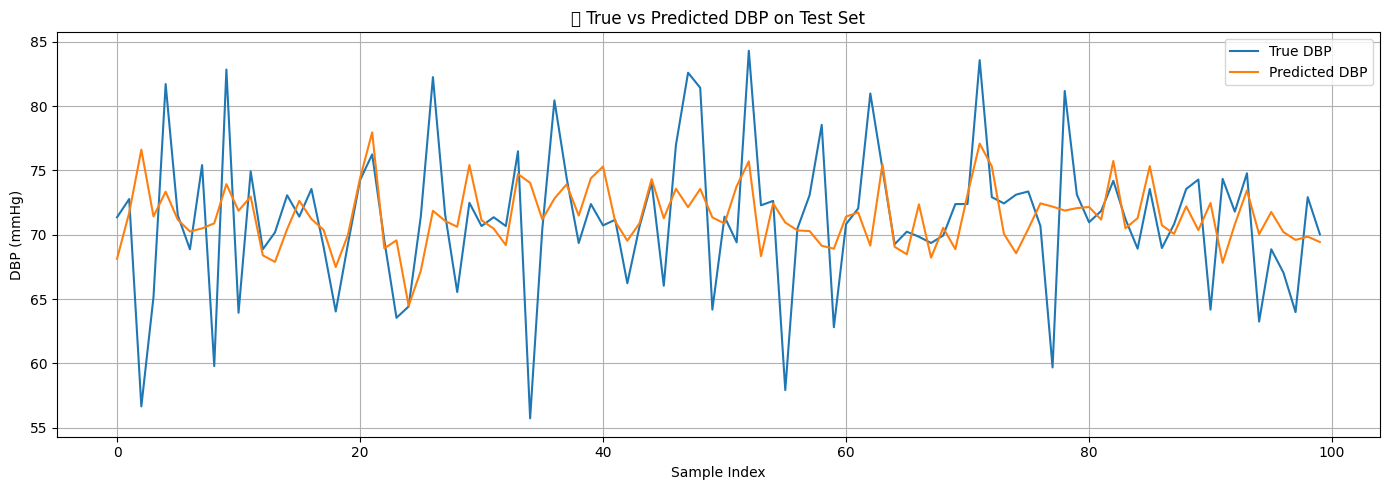

In [15]:
import matplotlib.pyplot as plt

y_test_sbp = y_test_all[:, 0]
y_test_dbp = y_test_all[:, 1]

# Dự đoán trên tập test
y_pred_sbp_test = rf_sbp.predict(X_test)
y_pred_dbp_test = rf_dbp.predict(X_test)

# Vẽ đồ thị SBP
plt.figure(figsize=(14, 5))
plt.plot(y_test_sbp[:100], label='True SBP')
plt.plot(y_pred_sbp_test[:100], label='Predicted SBP')
plt.title('📈 True vs Predicted SBP on Test Set')
plt.xlabel('Sample Index')
plt.ylabel('SBP (mmHg)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("bp_true_vs_predsbp.png", dpi=300)
plt.show()

# Vẽ đồ thị DBP
plt.figure(figsize=(14, 5))
plt.plot(y_test_dbp[:100], label='True DBP')
plt.plot(y_pred_dbp_test[:100], label='Predicted DBP')
plt.title('📉 True vs Predicted DBP on Test Set')
plt.xlabel('Sample Index')
plt.ylabel('DBP (mmHg)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("bp_true_vs_preddbp.png", dpi=300)
plt.show()


In [16]:
import joblib
joblib.dump(rf_sbp, 'rf_model_sbp3.pkl')
joblib.dump(rf_dbp, 'rf_model_dbp3.pkl')


['rf_model_dbp3.pkl']

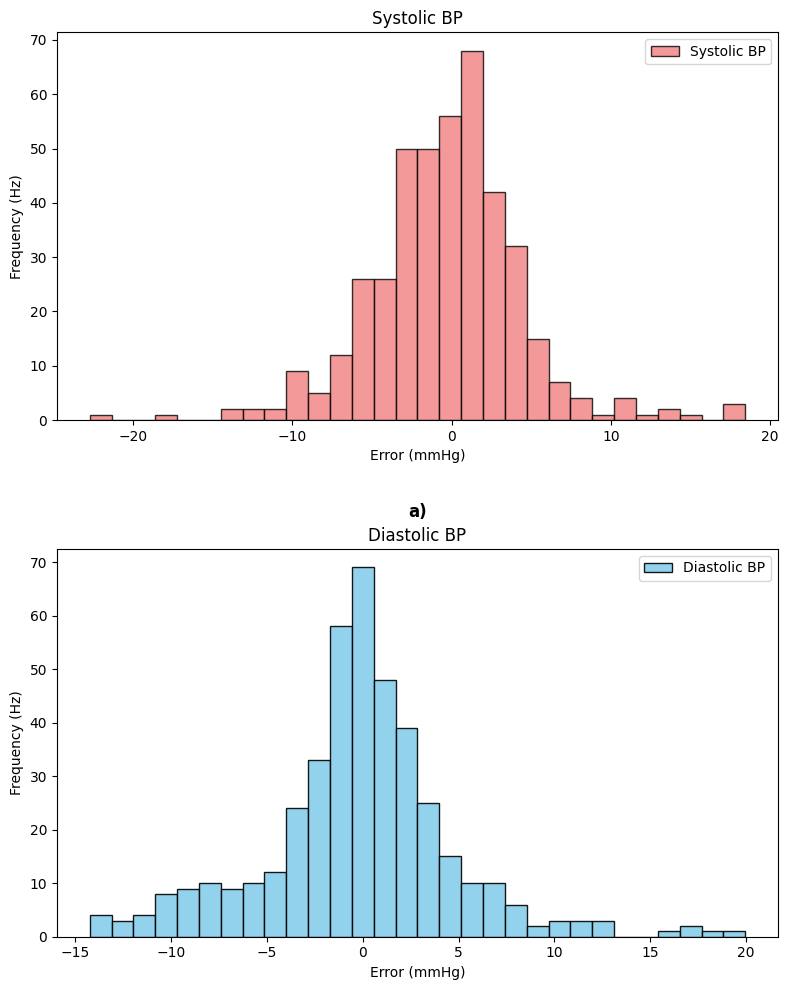

In [17]:
import matplotlib.pyplot as plt

# Tính sai số
error_sbp = sbp_test_pred.flatten() - y_sbp_test.flatten()
error_dbp = dbp_test_pred.flatten() - y_dbp_test.flatten()

# Vẽ histogram
fig, ax = plt.subplots(2, 1, figsize=(8, 10))

# Histogram SBP
ax[0].hist(error_sbp, bins=30, color='lightcoral', edgecolor='black', alpha=0.8, label='Systolic BP')
ax[0].set_title('Systolic BP')
ax[0].set_xlabel('Error (mmHg)')
ax[0].set_ylabel('Frequency (Hz)')
ax[0].legend()
ax[0].text(0.5, -0.25, 'a)', fontsize=12, fontweight='bold', transform=ax[0].transAxes, ha='center')

# Histogram DBP
ax[1].hist(error_dbp, bins=30, color='skyblue', edgecolor='black', alpha=0.9, label='Diastolic BP')
ax[1].set_title('Diastolic BP')
ax[1].set_xlabel('Error (mmHg)')
ax[1].set_ylabel('Frequency (Hz)')
ax[1].legend()

plt.tight_layout()
plt.savefig("bp_error_histogram.png", dpi=300, bbox_inches='tight')  # Lưu hình
plt.show()
